# Lesson 2.3 — The Navier-Stokes Equations

## Newton's Second Law for a Fluid

Imagine a tiny fluid element — a small parcel of air drifting through a room.
It has mass $\rho \, dV$. Newton's second law says $F = ma$. For this fluid parcel:

$$\underbrace{\rho \frac{D\mathbf{u}}{Dt}}_{ma} = \underbrace{-\nabla p}_{\text{pressure}} + \underbrace{\mu \nabla^2 \mathbf{u}}_{\text{viscosity}} + \underbrace{\rho \mathbf{g}}_{\text{gravity}}$$

where $D/Dt = \partial/\partial t + \mathbf{u} \cdot \nabla$ is the **material derivative** —
it tracks the fluid parcel as it moves. This is Newton's second law, nothing more.

---

## The Complete Incompressible Navier-Stokes System

Two equations, two unknowns ($\mathbf{u}$, $p$):

**Continuity** (mass conservation):
$$\nabla \cdot \mathbf{u} = 0$$

**Momentum** (Newton's second law for a fluid):
$$\frac{\partial \mathbf{u}}{\partial t} + (\mathbf{u} \cdot \nabla) \mathbf{u} = -\frac{1}{\rho}\nabla p + \nu \nabla^2 \mathbf{u}$$

where $\nu = \mu/\rho$ is the **kinematic viscosity** (m²/s).

In 2D (x-momentum, y-momentum, continuity):

$$\frac{\partial u}{\partial t} + u\frac{\partial u}{\partial x} + v\frac{\partial u}{\partial y} = -\frac{1}{\rho}\frac{\partial p}{\partial x} + \nu\left(\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}\right)$$

$$\frac{\partial v}{\partial t} + u\frac{\partial v}{\partial x} + v\frac{\partial v}{\partial y} = -\frac{1}{\rho}\frac{\partial p}{\partial y} + \nu\left(\frac{\partial^2 v}{\partial x^2} + \frac{\partial^2 v}{\partial y^2}\right)$$

$$\frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} = 0$$

---

## Anatomy of Each Term

| Term | Name | Physical role |
|------|------|---------------|
| $\partial \mathbf{u}/\partial t$ | Unsteady/inertia | Time rate of change |
| $(\mathbf{u}\cdot\nabla)\mathbf{u}$ | Convection | Momentum carried by flow (nonlinear!) |
| $-\nabla p / \rho$ | Pressure gradient | Pressure pushes from high to low |
| $\nu \nabla^2 \mathbf{u}$ | Viscous diffusion | Friction smooths velocity gradients |

The convective term is **nonlinear** ($\mathbf{u} \cdot \nabla \mathbf{u}$) — this is the source of
turbulence, instability, and computational difficulty.

---

## The Reynolds Number

Non-dimensionalise with length scale $L$ and velocity scale $U$:
Let $x = L \tilde{x}$, $\mathbf{u} = U \tilde{\mathbf{u}}$, $t = (L/U) \tilde{t}$, $p = \rho U^2 \tilde{p}$.

The momentum equation becomes:

$$\frac{\partial \tilde{\mathbf{u}}}{\partial \tilde{t}} + (\tilde{\mathbf{u}} \cdot \tilde{\nabla}) \tilde{\mathbf{u}} = -\tilde{\nabla} \tilde{p} + \frac{1}{Re} \tilde{\nabla}^2 \tilde{\mathbf{u}}$$

where $Re = UL/\nu$ is the **Reynolds number** — the single most important dimensionless
parameter in incompressible fluid mechanics.

- $Re \ll 1$: viscosity dominates — Stokes flow (creeping, laminar, reversible)
- $Re \sim 1$–$10^3$: laminar with structure (lid-driven cavity has steady recirculation)
- $Re > 10^3$–$10^4$: transition to turbulence
- $Re \gg 10^4$: fully turbulent (requires modelling, Module 03)


Couette flow: each N-S term
  Max |unsteady term|:   0.00e+00
  Max |convective term|: 0.00e+00
  Max |viscous term|:    1.69e-15  (linear profile → d²u/dy²=0 ✓)


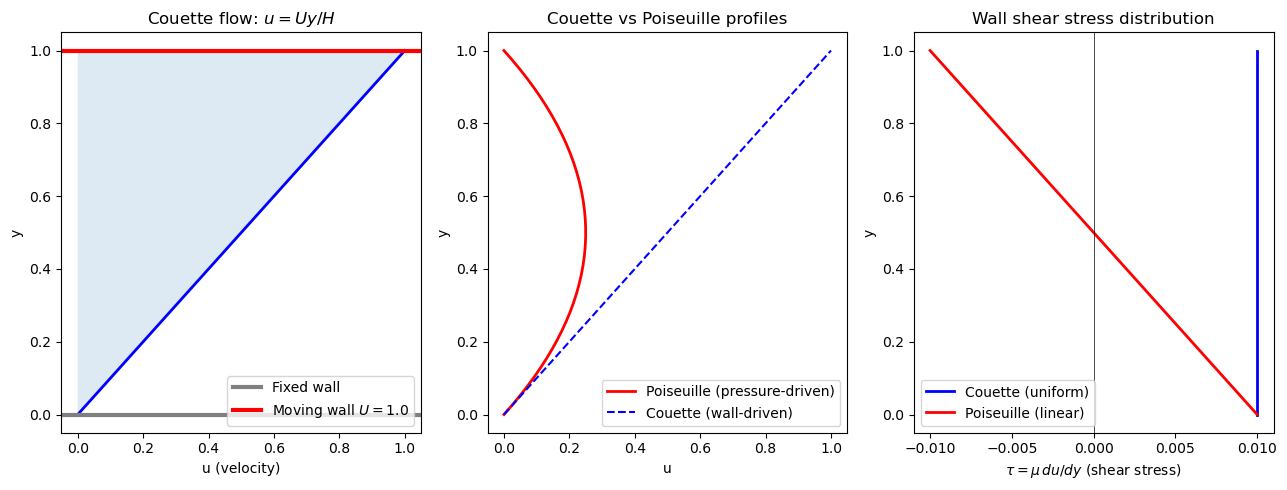

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Demonstrate the physical meaning of each N-S term
# Use a simple analytical flow: Couette flow (linear velocity profile)
# u(y) = U_top * y/H, v = 0, dp/dx = 0
# Exact N-S solution: viscous forces balance → d²u/dy² = 0

H = 1.0
U_top = 1.0
nu = 0.01
N = 40

y = np.linspace(0, H, N)
dy = y[1] - y[0]

u_couette = U_top * y / H
v_couette = np.zeros_like(y)

# Compute each term in y-direction momentum (should all be zero in steady Couette)
dudt = np.zeros_like(y)  # steady flow

# Convective: u * du/dy (with u=linear, du/dy=const, but v=0 so v*du/dy dominates)
# Actually: (u*du/dx + v*du/dy) = 0 since u doesn't depend on x and v=0
conv = np.zeros_like(y)

# Pressure gradient (zero for pure Couette)
dp_dx = np.zeros_like(y)

# Viscous: nu * d²u/dy²
d2u_dy2 = np.zeros_like(y)
d2u_dy2[1:-1] = (u_couette[2:] - 2*u_couette[1:-1] + u_couette[:-2]) / dy**2
visc = nu * d2u_dy2

print("Couette flow: each N-S term")
print(f"  Max |unsteady term|:   {np.max(np.abs(dudt)):.2e}")
print(f"  Max |convective term|: {np.max(np.abs(conv)):.2e}")
print(f"  Max |viscous term|:    {np.max(np.abs(visc)):.2e}  (linear profile → d²u/dy²=0 ✓)")

fig, axes = plt.subplots(1, 3, figsize=(13, 5))

# Couette velocity profile
axes[0].plot(u_couette, y, 'b-', linewidth=2)
axes[0].fill_betweenx(y, 0, u_couette, alpha=0.15)
axes[0].axhline(y=0, color='gray', linewidth=3, label='Fixed wall')
axes[0].axhline(y=H, color='red', linewidth=3, label=f'Moving wall $U={U_top}$')
axes[0].set_xlabel('u (velocity)')
axes[0].set_ylabel('y')
axes[0].set_title('Couette flow: $u = Uy/H$')
axes[0].legend()

# Poiseuille for comparison (driven by pressure gradient)
# dp/dx = -G → u(y) = G*y*(H-y)/(2*nu)
G = 2 * nu * U_top / H**2  # choose G to give same centerline speed
u_pois = G * y * (H - y) / (2 * nu)

axes[1].plot(u_pois, y, 'r-', linewidth=2, label='Poiseuille (pressure-driven)')
axes[1].plot(u_couette, y, 'b--', linewidth=1.5, label='Couette (wall-driven)')
axes[1].set_xlabel('u')
axes[1].set_ylabel('y')
axes[1].set_title('Couette vs Poiseuille profiles')
axes[1].legend()

# Shear stress: tau = mu * du/dy
mu = nu  # rho=1
tau_couette = mu * U_top / H * np.ones_like(y)  # constant shear
du_pois_dy  = G * (H - 2*y) / (2*nu)
tau_pois    = mu * du_pois_dy

axes[2].plot(tau_couette, y, 'b-', linewidth=2, label='Couette (uniform)')
axes[2].plot(tau_pois,    y, 'r-', linewidth=2, label='Poiseuille (linear)')
axes[2].set_xlabel('$\\tau = \\mu \\, du/dy$ (shear stress)')
axes[2].set_ylabel('y')
axes[2].set_title('Wall shear stress distribution')
axes[2].legend()
axes[2].axvline(0, color='k', linewidth=0.5)

plt.tight_layout()
plt.show()

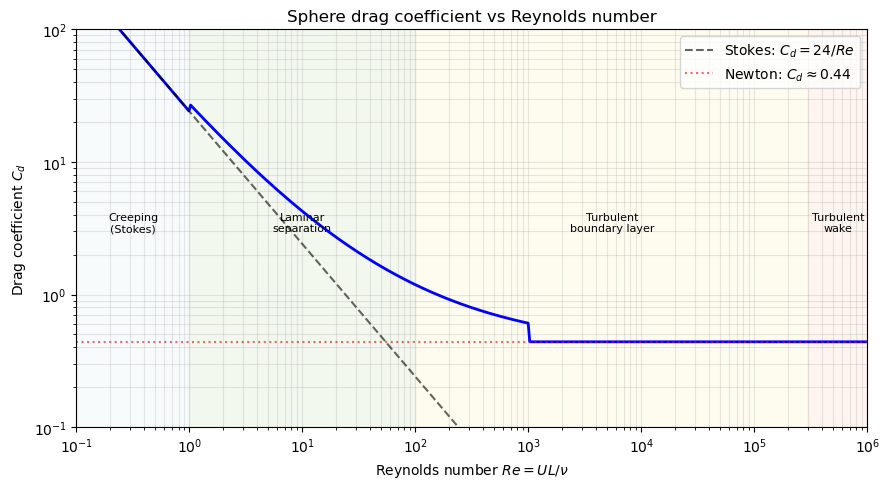

The Re number tells you which terms in the N-S equations dominate.


In [2]:
# Reynolds number effect: low Re vs high Re vortex shedding (conceptual)
# Stokes drag formula vs Newtonian inertia

import matplotlib.patches as mpatches

Re_values = np.logspace(-1, 6, 500)

# Drag coefficient for a sphere: Cd = 24/Re (Stokes, Re<<1) to Cd ~ 0.44 (Newton, Re>>1)
Cd = np.where(Re_values < 1, 24/Re_values,
     np.where(Re_values < 1000, 24/Re_values + 6/(1+np.sqrt(Re_values)) + 0.4,
              0.44))

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(Re_values, Cd, 'b-', linewidth=2)
ax.loglog(Re_values, 24/Re_values, 'k--', alpha=0.6, label='Stokes: $C_d = 24/Re$')
ax.axhline(0.44, color='r', linestyle=':', alpha=0.6, label='Newton: $C_d \\approx 0.44$')

# Annotate flow regimes
regions = [
    (0.1, 1, 'Creeping\n(Stokes)'),
    (1, 100, 'Laminar\nseparation'),
    (100, 3e5, 'Turbulent\nboundary layer'),
    (3e5, 1e6, 'Turbulent\nwake'),
]
colors = ['#e8f4f8', '#d4e8c8', '#fef3cd', '#fde0d0']
for (x1, x2, label), color in zip(regions, colors):
    ax.axvspan(x1, x2, alpha=0.3, color=color)
    ax.text(np.sqrt(x1*x2), 3, label, ha='center', fontsize=8)

ax.set_xlabel('Reynolds number $Re = UL/\\nu$')
ax.set_ylabel('Drag coefficient $C_d$')
ax.set_title('Sphere drag coefficient vs Reynolds number')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim(0.1, 1e6)
ax.set_ylim(0.1, 100)
plt.tight_layout()
plt.show()

print("The Re number tells you which terms in the N-S equations dominate.")

## Key Takeaways

- N-S = Newton's second law for a fluid + incompressibility constraint.
- The momentum equation has four terms: unsteady, convective (nonlinear), pressure, viscous.
- Non-dimensionalisation gives the **Reynolds number** $Re = UL/\nu$ — the key control parameter.
- Low $Re$: viscosity dominates, smooth laminar flow. High $Re$: inertia dominates, turbulence.
- The nonlinear convective term $(\mathbf{u}\cdot\nabla)\mathbf{u}$ is the source of all difficulty.
- For incompressible flow: pressure is not thermodynamic — it's a Lagrange multiplier enforcing $\nabla\cdot\mathbf{u}=0$.

---

**Next**: Lesson 2.4 — Pressure-Velocity Coupling: the incompressibility constraint and staggered grids.
